# 4_4. SVM kernelowy: kiedy prosta nie wystarcza

Liniowy SVM szuka granicy:

$$
f(x)=w^Tx+b.
$$

To oznacza, że w oryginalnych cechach próbuje rozdzielić klasy prostą, płaszczyzną albo hiperpłaszczyzną. Dla wielu problemów to za mało.

Kernel SVM robi coś sprytnego:

1. zachowuje ideę maksymalnego marginesu,
2. ale liczy podobieństwo punktów tak, jakby były przeniesione do bogatszej przestrzeni cech,
3. dzięki temu granica w oryginalnych cechach może być nieliniowa.

W wersji dualnej decyzja ma postać:

$$
f(x)=\sum_{i\in SV} \alpha_i y_i K(x_i,x)+b.
$$

Suma idzie efektywnie po **support vectors**. To ważne: po treningu nie wszystkie punkty muszą wpływać na decyzję, tylko te z niezerowym współczynnikiem $\alpha_i$.

Najczęstsze kernele:

$$
K_{\text{linear}}(x,z)=x^Tz
$$

$$
K_{\text{poly}}(x,z)=(\gamma x^Tz+c)^d
$$

$$
K_{\text{RBF}}(x,z)=\exp(-\gamma\lVert x-z\rVert^2).
$$

## Uwaga organizacyjna

Kernel SVM nadal jest SVM-em: szuka granicy z dużym marginesem.

Nie budujemy tutaj grafu ani macierzy sąsiedztwa. Macierz kernela może wyglądać jak macierz podobieństw między punktami, ale jej rola jest inna: trafia do optymalizacji SVM i zastępuje iloczyny skalarne w bogatszej przestrzeni cech.

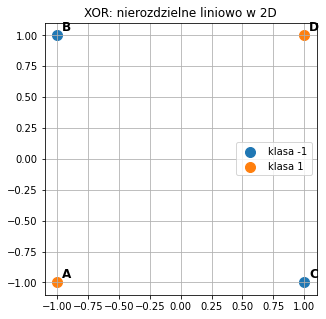

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.precision', 3)


def plot_points(X, labels, classes=None, title='', annotate=True, ax=None, test_points=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    X = np.asarray(X, dtype=float)
    if classes is None:
        ax.scatter(X[:, 0], X[:, 1], s=100)
    else:
        classes = np.asarray(classes)
        for c in sorted(set(classes)):
            idx = classes == c
            ax.scatter(X[idx, 0], X[idx, 1], s=100, label=f'klasa {c}')
        ax.legend()
    if annotate:
        for lab, (x, y_coord) in zip(labels, X):
            ax.text(x + 0.04, y_coord + 0.04, lab, fontsize=12, weight='bold')
    if test_points:
        for lab, pt in test_points.items():
            ax.scatter([pt[0]], [pt[1]], s=160, marker='*')
            ax.text(pt[0] + 0.06, pt[1] + 0.06, lab, fontsize=12, weight='bold')
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    return ax

# XOR: te same znaki na przekątnej należą do tej samej klasy.
X = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]], dtype=float)
y = np.array([1, -1, -1, 1])
labels = np.array(['A', 'B', 'C', 'D'])
plot_points(X, labels, classes=y, title='XOR: nierozdzielne liniowo w 2D')
plt.show()

## 1. Ręczna transformacja cech dla XOR

Dla XOR zwykła prosta w 2D nie wystarcza: punkty tej samej klasy leżą na przekątnych.

Ale dodajmy nową cechę:

$$
z=x_1x_2.
$$

Dla punktów:

- $(-1,-1)$: $z=1$,
- $(-1,1)$: $z=-1$,
- $(1,-1)$: $z=-1$,
- $(1,1)$: $z=1$.

Teraz klasy rozdzielają się przez prosty próg:

$$
z=0.
$$

To jest najważniejsza intuicja kernela: **problem może nie być liniowy w starych cechach, ale stać się liniowy po dodaniu nowych cech**.

In [2]:
z = X[:, 0] * X[:, 1]
phi_manual = pd.DataFrame({
    'punkt': labels,
    'x1': X[:, 0],
    'x2': X[:, 1],
    'nowa cecha z=x1*x2': z,
    'klasa': y,
})
display(phi_manual)

# W nowej jednowymiarowej cesze z wystarczy próg 0.
pred_from_z = np.where(z >= 0, 1, -1)
display(pd.DataFrame({
    'punkt': labels,
    'z': z,
    'predykcja z progu z>=0': pred_from_z,
    'prawdziwa klasa': y,
    'czy dobrze?': pred_from_z == y,
}))

,punkt,x1,x2,nowa cecha z=x1*x2,klasa
0,A,-1.0,-1.0,1.0,1
1,B,-1.0,1.0,-1.0,-1
2,C,1.0,-1.0,-1.0,-1
3,D,1.0,1.0,1.0,1


,punkt,z,predykcja z progu z>=0,prawdziwa klasa,czy dobrze?
0,A,1.0,1,1,True
1,B,-1.0,-1,-1,True
2,C,-1.0,-1,-1,True
3,D,1.0,1,1,True


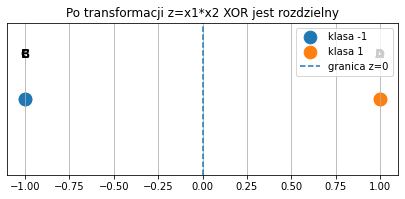

In [3]:
fig, ax = plt.subplots(figsize=(7,2.8))
for c in sorted(set(y)):
    idx = y == c
    ax.scatter(z[idx], np.zeros(idx.sum()), s=160, label=f'klasa {c}')
    for lab, zz in zip(labels[idx], z[idx]):
        ax.text(zz, 0.03, lab, ha='center', fontsize=12, weight='bold')
ax.axvline(0, linestyle='--', label='granica z=0')
ax.set_yticks([])
ax.set_title('Po transformacji z=x1*x2 XOR jest rozdzielny')
ax.legend()
plt.show()

### Co właśnie zrobiliśmy?

Nie zmieniliśmy etykiet ani modelu decyzyjnego. Zmieniliśmy **reprezentację danych**.

W starych cechach $(x_1,x_2)$ potrzebowalibyśmy krzywej granicy. W nowej cesze $z=x_1x_2$ wystarczy granica liniowa $z=0$.

Kernel trick pozwala robić podobne rzeczy bez ręcznego wymyślania wszystkich nowych cech.

## 2. Kernel trick — o co chodzi?

Wyobraźmy sobie transformację cech:

$$
\phi(x) = \text{nowe, bogatsze cechy punktu }x.
$$

Liniowy SVM w tej nowej przestrzeni używałby iloczynu:

$$
\phi(x)^T\phi(z).
$$

Kernel pozwala policzyć ten iloczyn bez jawnego tworzenia całego wektora $\phi(x)$:

$$
K(x,z)=\phi(x)^T\phi(z).
$$

Dlatego mówimy, że kernel jest funkcją podobieństwa zgodną z pewną przestrzenią cech.

Praktyczna interpretacja:

```text
linear  → porównujemy punkty przez zwykły iloczyn skalarny,
poly    → dopuszczamy potęgi i interakcje cech, np. x1*x2,
RBF     → każdy support vector działa lokalnie, jak „górka” podobieństwa.
```

Granica w przestrzeni $\phi(x)$ jest liniowa, ale po powrocie do oryginalnych osi może wyglądać jak krzywa.

### 2a. Macierz kernela: co algorytm naprawdę dostaje?

Dla punktów treningowych SVM może korzystać z macierzy:

$$
K_{ij}=K(x_i,x_j).
$$

To jest tabela podobieństw między parami punktów według wybranego kernela. Poniżej porównujemy trzy sposoby mierzenia podobieństwa dla tych samych czterech punktów XOR.

Ważne: kernel nie „zna” klas sam z siebie. Dopiero SVM uczy współczynniki $\alpha_i$, które mówią, jak wykorzystać te podobieństwa do klasyfikacji.

In [4]:
def kernel_linear(A, B):
    return A @ B.T


def kernel_poly2(A, B, gamma=1.0, coef0=0.0):
    return (gamma * (A @ B.T) + coef0) ** 2


def kernel_rbf(A, B, gamma=1.0):
    diff = A[:, None, :] - B[None, :, :]
    sqdist = np.sum(diff ** 2, axis=2)
    return np.exp(-gamma * sqdist)


def show_kernel_matrix(K, title):
    display(pd.DataFrame(np.round(K, 3), index=labels, columns=labels).style.set_caption(title))

show_kernel_matrix(kernel_linear(X, X), 'K linear = x^T z')
show_kernel_matrix(kernel_poly2(X, X), 'K polynomial degree 2 = (x^T z)^2')
show_kernel_matrix(kernel_rbf(X, X, gamma=1), 'K RBF, gamma=1')

,A,B,C,D
A,2.000000,0.000000,0.000000,-2.000000
B,0.000000,2.000000,-2.000000,0.000000
C,0.000000,-2.000000,2.000000,0.000000
D,-2.000000,0.000000,0.000000,2.000000


,A,B,C,D
A,4.000000,0.000000,0.000000,4.000000
B,0.000000,4.000000,4.000000,0.000000
C,0.000000,4.000000,4.000000,0.000000
D,4.000000,0.000000,0.000000,4.000000


,A,B,C,D
A,1.000000,0.018000,0.018000,0.000000
B,0.018000,1.000000,0.000000,0.018000
C,0.018000,0.000000,1.000000,0.018000
D,0.000000,0.018000,0.018000,1.000000


### 2b. Jak czytać różne kernele?

| kernel w `SVC` | co robi intuicyjnie | kiedy ma sens | ważne parametry |
|---|---|---|---|
| `linear` | szuka prostej/hiperpłaszczyzny w oryginalnych cechach | dużo cech, problem prawie liniowy, potrzeba prostoty | `C` |
| `poly` | dodaje interakcje i potęgi cech | zależności typu XOR, interakcje $x_1x_2$, krzywe wielomianowe | `degree`, `C`, `gamma`, `coef0` |
| `rbf` | porównuje punkty przez odległość; wpływ support vectora jest lokalny | dobry uniwersalny wybór dla nieliniowych danych tabelarycznych | `C`, `gamma` |
| `sigmoid` | przypomina funkcję aktywacji z sieci neuronowych | rzadziej jako pierwszy wybór; bywa wrażliwy na parametry | `C`, `gamma`, `coef0` |

To nie są zupełnie różne algorytmy uczenia. To ten sam schemat SVC, ale z inną definicją podobieństwa $K(x,z)$.

Zanim narysujemy granice, sprawdźmy liczbowo, co robią różne kernele na XOR.

- Liniowy SVM nie ma tu informacji, która pozwoliłaby oddzielić przekątne prostą w 2D.
- Kernel wielomianowy stopnia 2 potrafi reprezentować interakcję podobną do $x_1x_2$.
- RBF potrafi złożyć nieliniową granicę z lokalnych podobieństw do support vectors.

In [5]:
def svc_summary(kernel='rbf', C=10, gamma='scale', degree=3, coef0=0.0):
    clf = SVC(kernel=kernel, C=C, gamma=gamma, degree=degree, coef0=coef0)
    clf.fit(X, y)
    pred = clf.predict(X)
    return {
        'kernel': kernel,
        'C': C,
        'gamma': gamma,
        'degree': degree if kernel == 'poly' else '',
        'coef0': coef0 if kernel in ['poly', 'sigmoid'] else '',
        'trafność treningowa': np.mean(pred == y),
        'predykcje A,B,C,D': pred.tolist(),
        'support vectors': [labels[i] for i in clf.support_],
        'liczba support vectors': len(clf.support_),
    }

pd.DataFrame([
    svc_summary(kernel='linear', C=10),
    svc_summary(kernel='poly', C=10, degree=2, gamma='scale', coef0=0),
    svc_summary(kernel='rbf', C=10, gamma=1),
])

,kernel,C,gamma,degree,coef0,trafność treningowa,"predykcje A,B,C,D",support vectors,liczba support vectors
0,linear,10,scale,,,0.5,"[1, 1, 1, 1]","[B, C, A, D]",4
1,poly,10,scale,2,0,1.0,"[1, -1, -1, 1]","[C, D]",2
2,rbf,10,1,,,1.0,"[1, -1, -1, 1]","[B, C, A, D]",4


### 2c. Confusion matrix dla różnych kerneli na XOR

Tutaj confusion matrix bardzo dobrze pokazuje, **po co w ogóle potrzebujemy kernela**.

- Model liniowy próbuje rozdzielić XOR jedną prostą, więc miesza klasy.
- Kernel wielomianowy stopnia 2 potrafi wykorzystać interakcję podobną do $x_1x_2$.
- Kernel RBF składa nieliniową granicę z lokalnych podobieństw.

Wiersze macierzy to klasy prawdziwe, kolumny to predykcje. W idealnym przypadku liczby leżą tylko na przekątnej.

,pred -1,pred +1
true -1,0,2
true +1,0,2


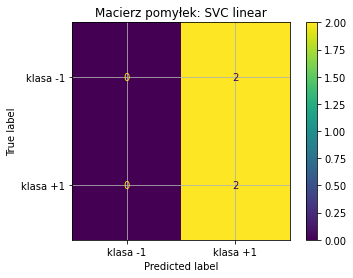

,pred -1,pred +1
true -1,2,0
true +1,0,2


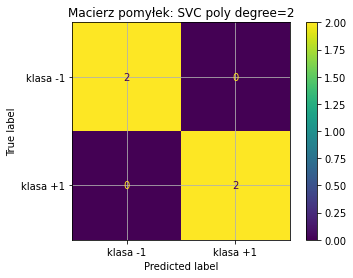

,pred -1,pred +1
true -1,2,0
true +1,0,2


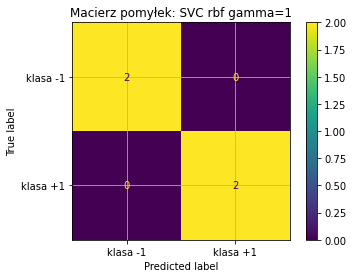

,model,accuracy treningowa,"predykcje A,B,C,D",support vectors
0,linear,0.5,"[1, 1, 1, 1]","[B, C, A, D]"
1,poly degree=2,1.0,"[1, -1, -1, 1]","[C, D]"
2,rbf gamma=1,1.0,"[1, -1, -1, 1]","[B, C, A, D]"


In [6]:
kernel_configs = [
    ('linear', dict(kernel='linear', C=10)),
    ('poly degree=2', dict(kernel='poly', C=10, degree=2, gamma='scale', coef0=0)),
    ('rbf gamma=1', dict(kernel='rbf', C=10, gamma=1)),
]

rows = []
for name, params in kernel_configs:
    clf = SVC(**params).fit(X, y)
    pred = clf.predict(X)
    cm = confusion_matrix(y, pred, labels=[-1, 1])
    rows.append({
        'model': name,
        'accuracy treningowa': accuracy_score(y, pred),
        'predykcje A,B,C,D': pred.tolist(),
        'support vectors': [labels[i] for i in clf.support_],
    })
    display(pd.DataFrame(cm, index=['true -1', 'true +1'], columns=['pred -1', 'pred +1']).style.set_caption(name))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['klasa -1', 'klasa +1']).plot()
    plt.title(f'Macierz pomyłek: SVC {name}')
    plt.show()

display(pd.DataFrame(rows))

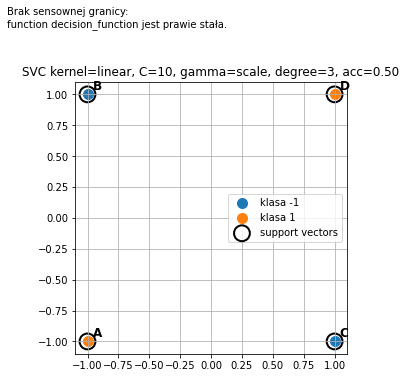

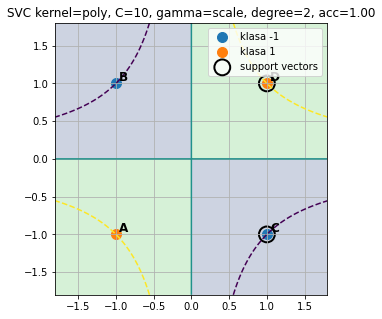

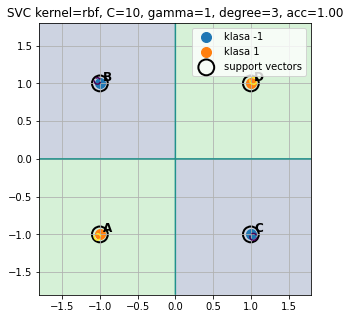

In [7]:
def plot_svc_boundary(kernel='rbf', C=10, gamma='scale', degree=3):
    clf = SVC(kernel=kernel, C=C, gamma=gamma, degree=degree)
    clf.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(-1.8, 1.8, 250), np.linspace(-1.8, 1.8, 250))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    pred_train = clf.predict(X)
    train_acc = np.mean(pred_train == y)

    fig, ax = plt.subplots(figsize=(6, 5))
    z_min, z_max = float(np.nanmin(Z)), float(np.nanmax(Z))

    if z_min < 0 < z_max:
        ax.contourf(xx, yy, Z > 0, alpha=0.25)
        levels = [level for level in [-1, 0, 1] if z_min <= level <= z_max]
        if levels:
            ax.contour(xx, yy, Z, levels=levels, linestyles=['--' if level != 0 else '-' for level in levels])
    else:
        ax.text(-1.65, 1.55, 'Brak sensownej granicy:\nfunction decision_function jest prawie stała.', fontsize=10)

    plot_points(
        X, labels, classes=y, ax=ax,
        title=f'SVC kernel={kernel}, C={C}, gamma={gamma}, degree={degree}, acc={train_acc:.2f}'
    )
    sv = clf.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=250, facecolors='none', edgecolors='black', linewidths=2, label='support vectors')
    ax.legend(loc='best')
    plt.show()

plot_svc_boundary(kernel='linear', C=10)
plot_svc_boundary(kernel='poly', C=10, degree=2, gamma='scale')
plot_svc_boundary(kernel='rbf', C=10, gamma=1)

### Jak interpretować narysowane granice?

- Przy `linear` zobaczysz brak sensownego rozdzielenia XOR — jedna prosta nie oddzieli przekątnych.
- Przy `poly degree=2` granica wynika z interakcji drugiego stopnia, więc pasuje do struktury XOR.
- Przy `rbf` granica jest składana z lokalnych wpływów support vectors. To bardzo elastyczne, ale przy złych parametrach może się przeuczyć.

W każdym przypadku predykcja nadal jest znakiem funkcji decyzyjnej:

$$
\hat y = \operatorname{sign}(f(x)).
$$

## 2d. Kernel SVM a drzewo decyzyjne na XOR

XOR jest też dobrym przykładem do porównania z drzewami decyzyjnymi. Oba podejścia mogą rozwiązać ten problem, ale robią to zupełnie inną geometrią.

**Kernel SVM** nadal myśli w kategoriach marginesu i podobieństw między punktami. Po dobraniu kernela granica może być nieliniowa, ale model wciąż optymalizuje separację z marginesem.

**Drzewo decyzyjne** nie używa marginesu. Buduje sekwencję prostych pytań:

```text
czy x1 <= próg?
czy x2 <= próg?
```

W 2D pojedyncze drzewo tworzy granice schodkowe, równoległe do osi. Dla XOR wystarczy drzewo głębokości 2, ale jego mechanizm jest inny niż kernel trick.


Reguły drzewa:
|--- x1 <= 0.00
|   |--- x2 <= 0.00
|   |   |--- class: 1
|   |--- x2 >  0.00
|   |   |--- class: -1
|--- x1 >  0.00
|   |--- x2 <= 0.00
|   |   |--- class: -1
|   |--- x2 >  0.00
|   |   |--- class: 1

Accuracy treningowe drzewa: 1.0


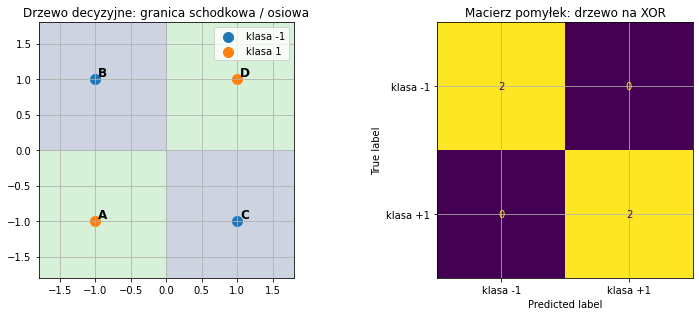

In [8]:
from sklearn.tree import DecisionTreeClassifier, export_text

# Drzewo głębokości 2 wystarcza do XOR: najpierw split po jednej osi,
# potem split po drugiej osi w obu gałęziach.
tree_xor = DecisionTreeClassifier(max_depth=2, random_state=42).fit(X, y)
pred_tree = tree_xor.predict(X)

print('Reguły drzewa:')
print(export_text(tree_xor, feature_names=['x1', 'x2']))
print('Accuracy treningowe drzewa:', round(accuracy_score(y, pred_tree), 3))

xx, yy = np.meshgrid(np.linspace(-1.8, 1.8, 250), np.linspace(-1.8, 1.8, 250))
Z_tree = tree_xor.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].contourf(xx, yy, Z_tree > 0, alpha=0.25)
plot_points(X, labels, classes=y, ax=axes[0], title='Drzewo decyzyjne: granica schodkowa / osiowa')
axes[0].legend(loc='best')

cm_tree = confusion_matrix(y, pred_tree, labels=[-1, 1])
ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['klasa -1', 'klasa +1']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Macierz pomyłek: drzewo na XOR')
plt.tight_layout()
plt.show()


## 3. RBF: wpływ parametru $\gamma$

Dla kernela RBF:

$$
K(x,z)=\exp(-\gamma\lVert x-z\rVert^2).
$$

Parametr $\gamma$ kontroluje, jak szybko podobieństwo spada z odległością.

```text
małe gamma  → dalekie punkty nadal są do siebie trochę podobne,
              granica jest gładsza, model ma mniejszą elastyczność;

duże gamma  → podobieństwo szybko spada,
              każdy support vector działa bardzo lokalnie,
              granica może być poszarpana i przeuczona.
```

Najważniejsza praktyczna intuicja:

```text
C kontroluje, jak bardzo karzemy naruszenia marginesu.
gamma kontroluje, jak lokalna jest nieliniowość RBF.
```

Najbardziej ryzykowne połączenie to zwykle **duże C + duże gamma**, bo model dostaje silną motywację, żeby dopasować się bardzo lokalnie do punktów treningowych.

,gamma,trafność treningowa,liczba support vectors,interpretacja
0,0.1,1.0,12,gładko / szeroko
1,0.5,1.0,8,gładko / szeroko
2,1.0,1.0,12,średnio lokalnie
3,5.0,1.0,25,bardzo lokalnie
4,20.0,1.0,51,bardzo lokalnie


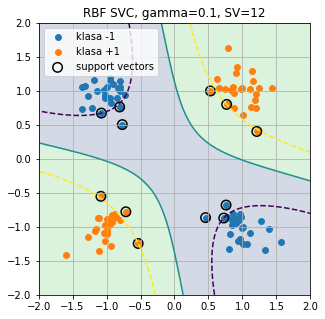

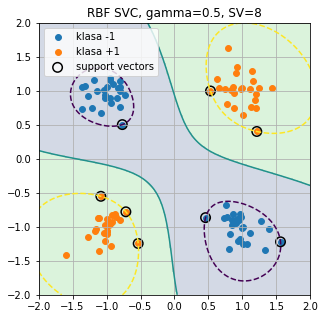

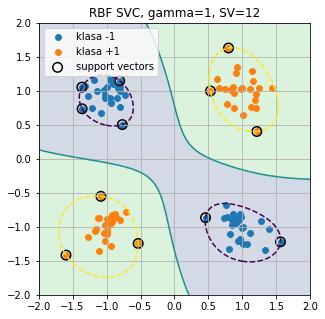

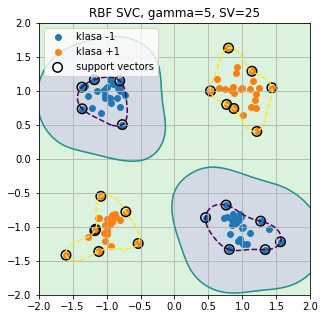

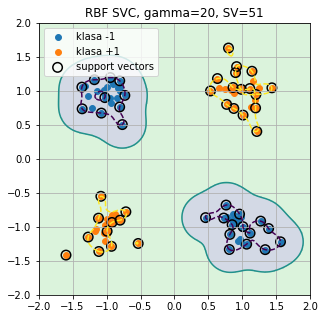

In [9]:
# Trochę większy zbiór podobny do XOR, żeby wpływ gamma był wyraźniejszy.
rng = np.random.default_rng(1)
centers = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]], dtype=float)
labels_big = np.array([1, -1, -1, 1])
X_big = np.vstack([rng.normal(loc=c, scale=0.22, size=(25, 2)) for c in centers])
y_big = np.repeat(labels_big, 25)


def boundary_for_gamma(gamma):
    clf = SVC(kernel='rbf', C=10, gamma=gamma)
    clf.fit(X_big, y_big)
    xx, yy = np.meshgrid(np.linspace(-2, 2, 180), np.linspace(-2, 2, 180))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.decision_function(grid).reshape(xx.shape)
    return clf, xx, yy, Z


gammas = [0.1, 0.5, 1, 5, 20]
summary_gamma = []
for gamma in gammas:
    clf, xx, yy, Z = boundary_for_gamma(gamma)
    summary_gamma.append({
        'gamma': gamma,
        'trafność treningowa': clf.score(X_big, y_big),
        'liczba support vectors': len(clf.support_),
        'interpretacja': 'gładko / szeroko' if gamma <= 0.5 else ('średnio lokalnie' if gamma <= 1 else 'bardzo lokalnie'),
    })
display(pd.DataFrame(summary_gamma))

# Statyczne rysunki są lżejsze od dużego interaktywnego slidera i łatwiej działają w różnych środowiskach.
for gamma in gammas:
    clf, xx, yy, Z = boundary_for_gamma(gamma)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.contourf(xx, yy, Z > 0, alpha=0.22)
    z_min, z_max = float(np.nanmin(Z)), float(np.nanmax(Z))
    levels = [level for level in [-1, 0, 1] if z_min <= level <= z_max]
    if levels:
        ax.contour(xx, yy, Z, levels=levels, linestyles=['--' if level != 0 else '-' for level in levels])
    ax.scatter(X_big[y_big == -1, 0], X_big[y_big == -1, 1], s=35, label='klasa -1')
    ax.scatter(X_big[y_big == 1, 0], X_big[y_big == 1, 1], s=35, label='klasa +1')
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=90, facecolors='none', edgecolors='black', linewidths=1.5, label='support vectors')
    ax.set_title(f'RBF SVC, gamma={gamma}, SV={len(clf.support_)}')
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='best')
    plt.show()


## 4. Co warto zapamiętać?

```text
SVC linear      → prosta / hiperpłaszczyzna w oryginalnych cechach
SVC polynomial  → granice wielomianowe; dobre do interakcji typu x1*x2
SVC RBF         → lokalne, elastyczne granice składane z podobieństw do support vectors
```

Najważniejsze idee:

- Kernel nie jest „magiczną sztuczką do rysowania krzywych”. To sposób liczenia iloczynu skalarnego w bogatszej przestrzeni cech.
- SVM z kernelem nadal maksymalizuje margines, ale robi to w przestrzeni cech $\phi(x)$.
- W oryginalnych osiach taka liniowa granica z przestrzeni $\phi(x)$ może wyglądać jak krzywa.
- `C` steruje karą za naruszenia marginesu.
- `gamma` w RBF steruje lokalnością podobieństwa.
- Kernel RBF jest mocny, ale bez skalowania i walidacji krzyżowej łatwo dobrać parametry za ostre albo za gładkie.
- Confusion matrix pomaga zobaczyć końcowe błędy klasyfikacji, ale nie wyjaśnia sama z siebie geometrii kernela; dlatego łączymy ją z rysunkiem granicy i support vectors.

- Drzewo decyzyjne też może rozwiązać problem nieliniowy, ale przez sekwencję progów na cechach, a nie przez kernel i margines.

Ten notebook pokazuje intuicję geometryczną. Kolejny notebook pokazuje praktyczny workflow: pipeline, skalowanie, walidację, dobór `C` i `gamma`, test oraz analizę błędów.
